In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install mne matplotlib pandas openneuro-py



In [7]:

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader , Subset
import mne
import openneuro
from tqdm import tqdm


In [8]:
dataset_id = "ds004504"

openneuro.download(
    dataset=dataset_id,
    target_dir="./data",
    include=["derivatives/"]
)

DATA_PATH = "./data/derivatives"


👋 Hello! This is openneuro-py 2026.4.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004504 …
📥 Retrieving up to 93 files (5 concurrent downloads). 

✅ Finished downloading ds004504.
 
🧠 Please enjoy your brains.
 


In [36]:
import pandas as pd
from collections import Counter

participants = pd.read_csv("./data/participants.tsv", sep="\t")
group_to_int = {"A": 0, "C": 1, "F": 2}
label_map = {
    row["participant_id"]: group_to_int[row["Group"]]
    for _, row in participants.iterrows()
}

class EEGSpectrogramDataset(Dataset):
    def __init__(self, root_dir, window_sec=30, fmin=1, fmax=40, training=False):
        self.samples = []
        self.labels = []
        self.subjects = []
        self.training = training

        for subject in sorted(os.listdir(root_dir)):
            eeg_folder = os.path.join(root_dir, subject, "eeg")
            if not os.path.exists(eeg_folder):
                continue
            label = label_map.get(subject)
            if label is None:
                continue

            for file in os.listdir(eeg_folder):
                if not file.endswith(".set"):
                    continue
                path = os.path.join(eeg_folder, file)
                try:
                    raw = mne.io.read_raw_eeglab(path, preload=True, verbose="ERROR")
                    raw.filter(1., 40., method="iir", verbose=False)
                    raw.pick("eeg")

                    sfreq = raw.info["sfreq"]
                    window_size = int(window_sec * sfreq)
                    data = raw.get_data()
                    n_channels, n_times = data.shape

                    for start in range(0, n_times - window_size, window_size):
                        window = data[:, start:start + window_size]
                        freqs = np.fft.rfftfreq(window_size, d=1.0 / sfreq)
                        mask = (freqs >= fmin) & (freqs <= fmax)
                        fft_mag = np.abs(np.fft.rfft(window, axis=1))[:, mask]
                        fft_mag = np.log1p(fft_mag)
                        fft_mag = (fft_mag - fft_mag.mean()) / (fft_mag.std() + 1e-6)
                        self.samples.append(fft_mag.astype(np.float32))
                        self.labels.append(label)
                        self.subjects.append(subject)

                except Exception as e:
                    print(f"skip {path}: {e}")

        print(f"total windows: {len(self.samples)} | dist: {Counter(self.labels)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x = torch.tensor(self.samples[idx]).unsqueeze(0)
        if self.training:
            x = x + 0.05 * torch.randn_like(x)
        return x, torch.tensor(self.labels[idx])


In [41]:
class SpectrogramCNN(nn.Module):
    def __init__(self, in_h, in_w, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [42]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), 100 * correct / total


In [43]:
ROOT = "./data/derivatives"
dataset = EEGSpectrogramDataset(ROOT, window_sec=30, training=False)

subjects = np.array(dataset.subjects)
labels = np.array(dataset.labels)
unique_subjects = np.array(sorted(set(subjects)))

n_subjects = len(unique_subjects)
np.random.seed(42)
shuffled = np.random.permutation(n_subjects)
n_val = max(1, int(0.2 * n_subjects))
val_subjects   = set(unique_subjects[shuffled[:n_val]])
train_subjects = set(unique_subjects[shuffled[n_val:]])

train_idx = [i for i, s in enumerate(subjects) if s in train_subjects]
val_idx   = [i for i, s in enumerate(subjects) if s in val_subjects]

print(f"train windows: {len(train_idx)} | val windows: {len(val_idx)}")
print(f"train subjects: {len(train_subjects)} | val subjects: {len(val_subjects)}")

train_labels = labels[train_idx]
counts = Counter(train_labels)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = torch.tensor(
    [len(train_labels) / (3 * counts[i]) for i in range(3)], dtype=torch.float32
).to(device)

dataset.training = True
train_loader = DataLoader(Subset(dataset, train_idx), batch_size=16, shuffle=True, num_workers=2)
dataset.training = False
val_loader   = DataLoader(Subset(dataset, val_idx),   batch_size=16, shuffle=False, num_workers=2)

sample_x, _ = dataset[0]
_, H, W = sample_x.shape
model = SpectrogramCNN(in_h=H, in_w=W, num_classes=3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5)

best_acc = 0.0
num_epochs = 30

for epoch in range(num_epochs):
    dataset.training = True
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    dataset.training = False
    vl_loss, vl_acc = run_epoch(model, val_loader, criterion, optimizer, device, train=False)
    scheduler.step(vl_acc)

    marker = " *" if vl_acc > best_acc else ""
    print(f"[{epoch+1:02d}/{num_epochs}] loss {tr_loss:.4f} acc {tr_acc:.1f}% | val loss {vl_loss:.4f} acc {vl_acc:.1f}%{marker}")

    torch.save(model.state_dict(), "latest_spectrogram_cnn.pth")
    if vl_acc > best_acc:
        best_acc = vl_acc
        torch.save(model.state_dict(), "best_spectrogram_cnn.pth")

print(f"done. best val acc: {best_acc:.1f}%")

total windows: 2285 | dist: Counter({0: 953, 1: 790, 2: 542})
train windows: 1871 | val windows: 414
train subjects: 71 | val subjects: 17
[01/30] loss 1.0383 acc 45.2% | val loss 1.0544 acc 53.6% *
[02/30] loss 0.8384 acc 64.8% | val loss 1.3096 acc 44.0%
[03/30] loss 0.7468 acc 71.6% | val loss 1.2811 acc 39.4%
[04/30] loss 0.6934 acc 71.9% | val loss 1.2942 acc 45.9%
[05/30] loss 0.6324 acc 73.7% | val loss 1.3359 acc 48.8%
[06/30] loss 0.5580 acc 77.3% | val loss 1.5386 acc 48.3%
[07/30] loss 0.4809 acc 81.0% | val loss 1.3381 acc 48.6%
[08/30] loss 0.4560 acc 82.7% | val loss 1.4702 acc 48.6%
[09/30] loss 0.4004 acc 84.8% | val loss 1.6840 acc 44.9%
[10/30] loss 0.3603 acc 86.1% | val loss 1.5907 acc 44.4%
[11/30] loss 0.3642 acc 86.4% | val loss 1.7551 acc 47.6%
[12/30] loss 0.2930 acc 89.3% | val loss 1.8155 acc 47.1%
[13/30] loss 0.2795 acc 90.3% | val loss 1.8148 acc 46.6%
[14/30] loss 0.2575 acc 90.9% | val loss 1.8260 acc 45.4%
[15/30] loss 0.2488 acc 91.9% | val loss 1.7983

train subjects: 0
val subjects: 0
train label dist: Counter()
val label dist: Counter()


  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14
3        sub-004      F   67     A    20
4        sub-005      M   70     A    22
5        sub-006      F   61     A    14
6        sub-007      F   79     A    20
7        sub-008      M   62     A    16
8        sub-009      F   77     A    23
9        sub-010      M   69     A    20
['A' 'C' 'F']


[01/30] loss 0.8962 acc 61.3% | val loss 1.0435 acc 53.1% *
[02/30] loss 0.8622 acc 64.6% | val loss 1.0478 acc 53.1%
[03/30] loss 0.8611 acc 63.4% | val loss 1.0571 acc 51.9%
[04/30] loss 0.8568 acc 64.7% | val loss 1.0533 acc 50.2%
[05/30] loss 0.8509 acc 63.8% | val loss 1.0674 acc 46.9%
[06/30] loss 0.8419 acc 64.5% | val loss 1.0772 acc 46.4%
[07/30] loss 0.8446 acc 65.7% | val loss 1.0826 acc 48.1%
[08/30] loss 0.8418 acc 65.3% | val loss 1.0816 acc 47.3%
[09/30] loss 0.8414 acc 65.2% | val loss 1.0836 acc 45.9%
early stop at epoch 9
done. best val acc: 53.1%


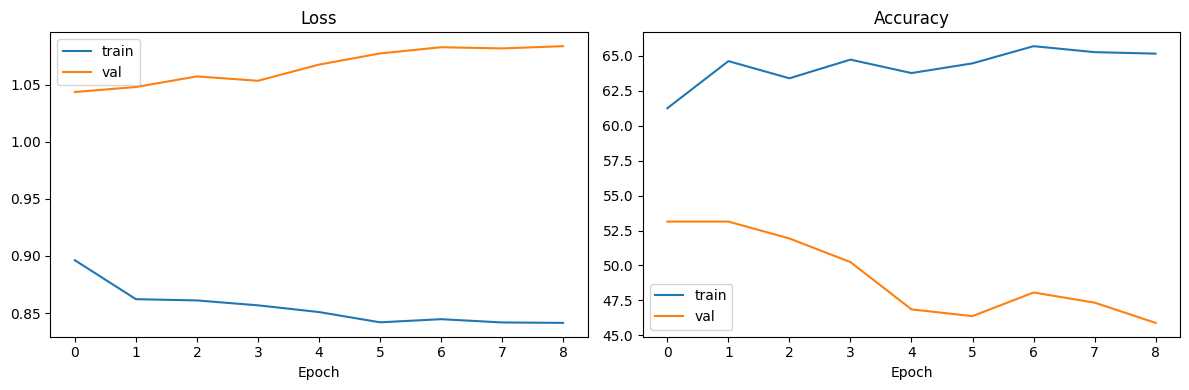

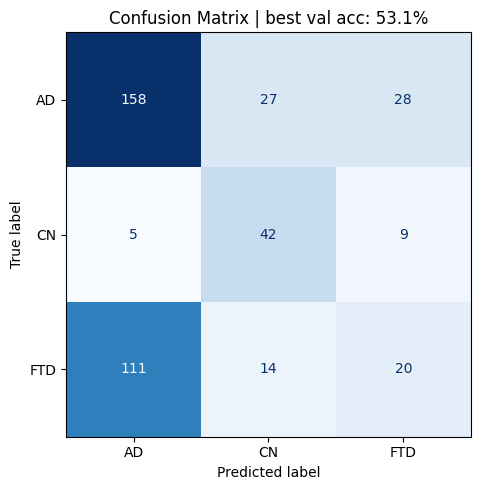

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train_losses, val_losses = [], []
train_accs, val_accs = [], []

model.load_state_dict(torch.load("best_spectrogram_cnn.pth"))

best_acc = 0.0
patience_counter = 0
patience = 8
num_epochs = 30

for epoch in range(num_epochs):
    dataset.training = True
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    dataset.training = False
    vl_loss, vl_acc = run_epoch(model, val_loader, criterion, optimizer, device, train=False)
    scheduler.step(vl_acc)

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    marker = " *" if vl_acc > best_acc else ""
    print(f"[{epoch+1:02d}/{num_epochs}] loss {tr_loss:.4f} acc {tr_acc:.1f}% | val loss {vl_loss:.4f} acc {vl_acc:.1f}%{marker}")

    if vl_acc > best_acc:
        best_acc = vl_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_spectrogram_cnn.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"early stop at epoch {epoch+1}")
            break

print(f"done. best val acc: {best_acc:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs, label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

model.load_state_dict(torch.load("best_spectrogram_cnn.pth"))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

class_names = ["AD", "CN", "FTD"]
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix | best val acc: {best_acc:.1f}%")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()